# Task 2 — Leaderboard Challenge


## 0. The Data and Forecasting Setup

In [1]:
import os
import sys
import inspect
from pathlib import Path

for candidate in (Path("src"), Path("Question 2 - Leaderboard/src"), Path("../src")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep src/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

import data
import validate
import figures
import replicate
import reporting as report
from autoformer import AutoCorrelation, Autoformer, SeriesDecomp, aggregate_delays, run_self_tests
from study import PRESETS, Study
from train import CONFIGS, HP, build_model

def show(obj):
    display(Markdown(f"```python\n{inspect.getsource(obj)}```"))

preset = os.environ.get("PA2_PRESET", "full")
torch.set_num_threads(max(1, os.cpu_count() or 1))
study = Study(preset)
cov_raw = data.load_external()
print(f"preset={preset}: {PRESETS[preset]}")
print(f"history: {study.n} observations; covariates: {cov_raw.shape}")
print(f"training windows end before index {study.train_end}; "
      f"early-stop weeks start {study.es_origins}; "
      f"evaluation weeks start {study.eval_origins[0]}..{study.eval_origins[-1]}")

preset=full: {'configs': ['A', 'B', 'C'], 'seeds': [0, 1, 2], 'epochs': 12, 'stride': 3, 'patience': 3}
history: 43656 observations; covariates: (43824, 10)
training windows end before index 40968; early-stop weeks start [40968, 41136, 41304, 41472]; evaluation weeks start 41640..43488


### Evidence

Output 0.1


,statistic,value
0,observations,43656.00
1,mean,98.17
2,std,90.83
3,min,0.00
4,max,994.00
5,exact zeros,2.00
6,skewness,1.83
7,excess kurtosis,5.00
8,quantile 1,6.00
9,quantile 5,10.00


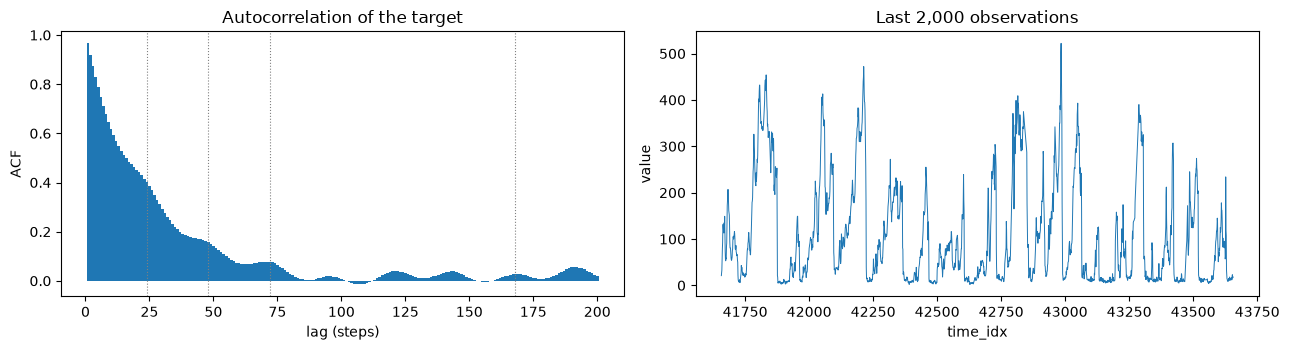

In [2]:
profile = figures.data_profile(study.y)
assert abs(study.y.mean() - 98.174) < 0.01 and abs(data.acf(study.y, 24) - 0.401) < 0.001, \
    "profile does not match FINDINGS: check loading / alignment"
assert np.allclose(cov_raw[:, 6:].sum(axis=1), 1.0), "feature_G..J should be one-hot"
figures.acf_and_recent(study.y)
report.publish("0.1", profile)

In [3]:
report.publish("0.2", figures.periodicity(study.y))

Output 0.2


,period,variance_share_pct,profile_peak_to_trough
0,12,0.10,7.70
1,24,0.99,26.95
2,48,1.01,29.38
3,168,1.19,43.49
4,720,1.93,63.03
5,8766,20.36,345.40


In [4]:
report.publish("0.3", figures.covariate_correlations(study.y, cov_raw))

Output 0.3


,feature,pearson,rank
0,feature_D,-0.24,-0.35
1,feature_H,-0.21,-0.33
2,feature_A,0.17,0.29
3,feature_I,0.10,0.21
4,feature_J,0.15,0.18
5,feature_C,-0.05,-0.14
6,feature_G,-0.03,-0.06
7,feature_E,0.02,0.05
8,feature_B,-0.09,0.01
9,feature_F,-0.05,-0.00


#### Output 0.4 — can the architecture reach the annual cycle?

In [5]:
def harmonic_r2(y, period, max_harmonics=6):
    t = np.arange(1, len(y) + 1, dtype=float)
    rows = []
    for h in range(1, max_harmonics + 1):
        cols = [np.ones(len(y))]
        for k in range(1, h + 1):
            angle = 2 * np.pi * k * t / period
            cols += [np.sin(angle), np.cos(angle)]
        coef, *_ = np.linalg.lstsq(np.column_stack(cols), y, rcond=None)
        resid = y - np.column_stack(cols) @ coef
        rows.append(resid.var())
    return 1 - min(rows) / y.var()           # best R^2 over 1..max_harmonics, same period


rows = []
for name, period in data.PROFILE_PERIODS.items():
    sin_cos_r2 = harmonic_r2(study.y, period)
    profile = data.seasonal_profile(study.y, study.train_end, study.n, period)
    profile_r2 = 1 - (study.y - profile).var() / study.y.var()
    rows.append(dict(period=period, sin_cos_best_r2=sin_cos_r2, phase_mean_profile_r2=profile_r2))
comparison = pd.DataFrame(rows)

gap = comparison.loc[comparison.period == 8766, "phase_mean_profile_r2"].item() - \
     comparison.loc[comparison.period == 8766, "sin_cos_best_r2"].item()
assert gap > 0.1, "expected the phase-mean profile to beat sin/cos by a wide margin at the annual period"
report.publish("0.4", comparison.round(4))

Output 0.4


,period,sin_cos_best_r2,phase_mean_profile_r2
0,24,0.01,0.01
1,168,0.00,0.01
2,8766,0.02,0.19


## 1. Validation Protocol and Baselines

Output 1.1


,method,rmse_mean,rmse_std,mae_mean,smape_mean,mean_rank,expected (FINDINGS §6)
0,damped persistence -> mean last 720,107.06,23.24,84.73,86.50,3.33,107.31
1,global mean,109.15,29.32,88.22,91.97,3.25,109.15
2,mean of last 168,111.64,29.01,90.62,90.93,3.17,111.64
3,"hour-of-day mean, last 28 days",113.12,23.55,91.53,92.13,3.75,113.12
4,median of last 720,114.67,35.84,87.01,93.61,4.83,114.67
5,mean of last 720,114.73,23.72,93.51,93.82,4.67,114.73
6,seasonal naive (repeat last 168),157.85,35.60,121.93,108.74,7.33,157.85
7,persistence (repeat last value),173.98,106.94,142.48,104.12,5.67,173.98


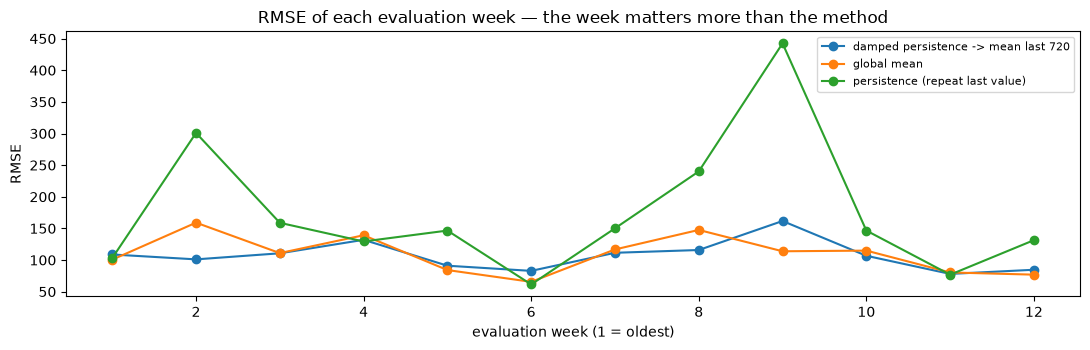

In [6]:
per_block = validate.run_baselines(study.y, study.eval_origins)
baselines = validate.summarise(per_block).reset_index()
baselines["expected (FINDINGS §6)"] = baselines["method"].map(validate.EXPECTED_RMSE)
gap = (baselines["rmse_mean"] - baselines["expected (FINDINGS §6)"]).abs()
assert (gap <= 1.0).all(), f"baseline gate failed:\n{baselines[gap > 1.0]}"
figures.baseline_blocks(per_block, ["damped persistence -> mean last 720", "global mean",
                                    "persistence (repeat last value)"])
report.publish("1.1", baselines)

## 2. Series Decomposition — mechanism

In [7]:
show(SeriesDecomp)

```python
class SeriesDecomp(nn.Module):
    """Centred moving average with replicate padding. seasonal + trend == x exactly."""

    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x):                                   # [B,L,C] -> (seasonal, trend)
        radius = self.kernel // 2
        padded = F.pad(x.transpose(1, 2), (radius, radius), mode="replicate")
        trend = F.avg_pool1d(padded, kernel_size=self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend
```

In [7]:
x = torch.tensor([1., 1., 2., 5., 5.]).view(1, 5, 1)
seasonal, trend = SeriesDecomp(3)(x)
assert torch.allclose(trend.view(-1), torch.tensor([1., 4/3, 8/3, 4., 5.])), "endpoint rule wrong"
assert torch.allclose(seasonal + trend, x), "seasonal + trend must equal x"
c = torch.full((1, 40, 1), 3.7)
assert torch.allclose(SeriesDecomp(25)(c)[1], c), "a constant series must have a constant trend"
print("decomposition checks passed; trend =", trend.view(-1).numpy().round(3))

decomposition checks passed; trend = [1.    1.333 2.667 4.    5.   ]


Output 2.1


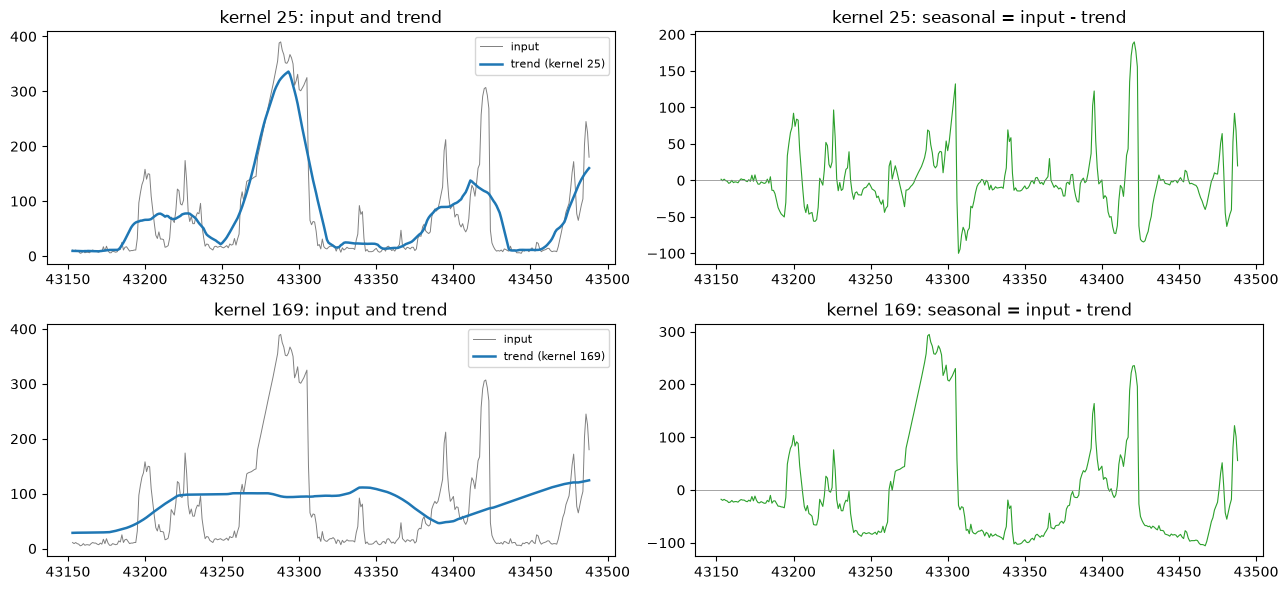

In [8]:
figures.decomposition(study.y, study.eval_origins[-1], L=HP["L_in"], kernels=(25, 169))
report.publish("2.1")

## 3. Auto-Correlation — mechanism

In [10]:
show(AutoCorrelation.forward)
show(aggregate_delays)

```python
    def forward(self, q_in, k_in, v_in):
        batch, len_q, width = q_in.shape
        len_k = k_in.shape[1]
        heads, head_dim = self.heads, width // self.heads
        q = self.q_proj(q_in).view(batch, len_q, heads, head_dim)
        k = self.k_proj(k_in).view(batch, len_k, heads, head_dim)
        v = self.v_proj(v_in).view(batch, len_k, heads, head_dim)
        if len_k > len_q:                                   # align keys/values to the query length
            k, v = k[:, :len_q], v[:, :len_q]
        elif len_k < len_q:
            pad = len_q - len_k
            k, v = F.pad(k, (0, 0, 0, 0, 0, pad)), F.pad(v, (0, 0, 0, 0, 0, pad))
        q, k, v = (t.permute(0, 2, 3, 1) for t in (q, k, v))            # [B,H,dh,Lq]

        # 1) similarity of the series with itself shifted by every delay, all at once via FFT
        qs, ks = q - q.mean(-1, keepdim=True), k - k.mean(-1, keepdim=True)
        corr = torch.fft.irfft(torch.fft.rfft(qs, dim=-1) * torch.fft.rfft(ks, dim=-1).conj(),
                               n=len_q, dim=-1)                          # [B,H,dh,Lq]
        scores = corr.mean(2)                                            # [B,H,Lq] one per delay

        # 2) keep the top-k delays, k = factor * log(L)
        top = max(1, min(int(self.factor * math.log(max(len_q, 2))), len_q))
        weight, delay = scores.topk(top, dim=-1)                         # [B,H,K]
        weight = weight.softmax(-1)

        # 3) time-delay aggregation: weighted sum of V rolled by each chosen delay
        mixed = aggregate_delays(v, delay, weight)
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, len_q, width))
```

```python
def aggregate_delays(values, delays, weights):
    """Time-delay aggregation (same contract as Question 1's `aggregate_delays`).
    values [B,H,dh,L]; delays, weights [B,H,K]. Output position t reads values[t - delay]
    (circularly), weighted: z_t = sum_j weights_j * values[(t - delays_j) mod L]."""
    batch, heads, head_dim, length = values.shape
    positions = torch.arange(length, device=values.device)
    mixed = torch.zeros_like(values)
    for j in range(delays.shape[-1]):
        src = (positions.view(1, 1, length) - delays[..., j:j + 1]) % length
        index = src.long().unsqueeze(2).expand(batch, heads, head_dim, length)
        mixed = mixed + weights[..., j].view(batch, heads, 1, 1) * values.gather(-1, index)
    return mixed
```

In [9]:
t = np.arange(96)
scores = figures.delay_scores_raw(np.sin(2 * np.pi * t / 24))
assert set(np.argsort(scores)[::-1][:4]) == {0, 24, 48, 72}, "delay scores do not find the period"

v = torch.tensor([10., 20., 30., 40.]).view(1, 1, 1, 4)
z = aggregate_delays(v, torch.tensor([[[1, 3]]]), torch.tensor([[[0.75, 0.25]]]))
assert torch.isclose(z[0, 0, 0, 0], torch.tensor(35.)), f"z0 = {z[0,0,0,0]}: aggregation rolls the wrong way"
print("auto-correlation checks passed; z =", z.view(-1).tolist())

auto-correlation checks passed; z = [35.0, 15.0, 25.0, 25.0]


Output 3.1


,delay,windows_selecting,delay_mod_24,share_of_windows
0,0,12,0,1.0
1,1,12,1,1.0
2,2,12,2,1.0
3,3,12,3,1.0
4,4,12,4,1.0
5,5,12,5,1.0
6,331,12,19,1.0
7,332,12,20,1.0
8,333,12,21,1.0
9,334,12,22,1.0


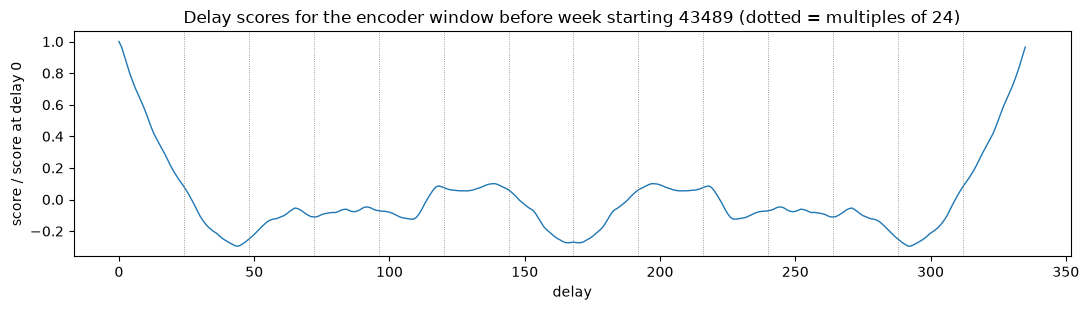

In [10]:
figures.delay_score_plot(study.y, study.eval_origins[-1], L=HP["L_in"])
report.publish("3.1", figures.delay_selection(study.y, study.eval_origins, L=HP["L_in"]).head(15))

## 4. Assemble the Autoformer

In [13]:
show(Autoformer.forward)
print("hyperparameters:", HP)

```python
    def forward(self, x_enc, x_dec_cov=None):
        """x_enc [B, L_in, enc_in]: target in channel 0, past covariates after it.
           x_dec_cov [B, label_len + pred_len, dec_in - 1]: covariates known over the horizon
           (may be None or zero-width when not used). Returns [B, pred_len]."""
        batch = x_enc.shape[0]
        seasonal_hist, trend_hist = self.decomp(x_enc[..., :1])

        # Conservative decoder init: trend continues at the recent LEVEL, seasonal starts at zero.
        # So an untrained model already forecasts "recent level, flat" and learns deviations from it.
        level = x_enc[:, -self.label_len:, :1].mean(1, keepdim=True)
        horizon_trend = level.expand(batch, self.pred_len, 1)
        if self.damping is not None:
            steps = torch.arange(1, self.pred_len + 1, device=x_enc.device, dtype=x_enc.dtype)
            decay = torch.sigmoid(self.damping) ** steps.view(1, -1, 1)
            horizon_trend = level + (x_enc[:, -1:, :1] - level) * decay
        trend_init = torch.cat([trend_hist[:, -self.label_len:], horizon_trend], dim=1)
        seasonal_init = torch.cat(
            [seasonal_hist[:, -self.label_len:],
             torch.zeros(batch, self.pred_len, 1, device=x_enc.device, dtype=x_enc.dtype)], dim=1)

        memory = self.enc_embed(x_enc.transpose(1, 2)).transpose(1, 2)
        for layer in self.encoder:
            memory = layer(memory)
        memory = self.enc_norm(memory)

        dec_in = seasonal_init if x_dec_cov is None else torch.cat([seasonal_init, x_dec_cov], -1)
        x = self.dec_embed(dec_in.transpose(1, 2)).transpose(1, 2)
        trend = trend_init
        for layer in self.decoder:
            x, delta = layer(x, memory)
            trend = trend + delta
        out = self.seasonal_proj(self.dec_norm(x)) + trend
        return out[:, -self.pred_len:, 0]                                  # [B, pred_len]
```

hyperparameters: {'L_in': 336, 'label_len': 168, 'pred_len': 168, 'd': 32, 'heads': 4, 'e_layers': 1, 'd_layers': 1, 'kernel': 25, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 32}


In [11]:
run_self_tests()
rows = []
for name, cfg in CONFIGS.items():
    model = build_model(cfg)
    rows.append(dict(config=name, covariates=len(cfg["features"]), past_cov=cfg["past_cov"],
                     future_cov=cfg["future_cov"], encoder_channels=model.enc_embed.in_channels,
                     decoder_channels=model.dec_embed.in_channels,
                     P=sum(p.numel() for p in model.parameters() if p.requires_grad)))
report.publish("4.1", pd.DataFrame(rows))

P target-only = 21,441   P with 10 covariates = 23,361   budget = 40,000
All 7 Autoformer self-tests passed.
Output 4.1


,config,covariates,past_cov,future_cov,encoder_channels,decoder_channels,P
0,A,0,False,False,1,1,21441
1,B,10,True,False,11,1,22401
2,C,10,True,True,11,11,23361
3,C_subset,4,True,True,5,5,22209
4,C_cal,11,True,True,12,12,23553
5,C_small,10,True,True,11,11,6561
6,C_small_wl,10,True,True,11,11,6561
7,C_small_wlr,10,True,True,11,11,6561
8,C_small_wlrd,10,True,True,11,11,6562
9,C_small_d,10,True,True,11,11,6562


## 5. Covariate Ablation

In [12]:
configs = PRESETS[preset]["configs"] + ["C_cal", "C_small",                       # architecture
                                        "C_small_wl", "C_small_wlr", "C_small_wlrd",  # training-time
                                        "C_small_d"]
seeds = PRESETS[preset]["seeds"]
study.run_all(configs, seeds)
report.publish("5.1", study.ablation_summary())

loaded full-A-seed0-bdc63d3325.pt
loaded full-A-seed1-973d5713a9.pt
loaded full-A-seed2-914c0d467f.pt
loaded full-B-seed0-5a6c5d060d.pt
loaded full-B-seed1-f8ec29c0da.pt
loaded full-B-seed2-973aa7d1b6.pt
loaded full-C-seed0-de70b108cb.pt
loaded full-C-seed1-35eecdba25.pt
loaded full-C-seed2-8d3636ec98.pt
loaded full-C_cal-seed0-b97edfd91d.pt
loaded full-C_cal-seed1-06ec9e0f50.pt
loaded full-C_cal-seed2-db3aff7c0d.pt
loaded full-C_small-seed0-4b622d5b1a.pt
loaded full-C_small-seed1-3ca1946240.pt
loaded full-C_small-seed2-e73c7f9ea7.pt
loaded full-C_small_wl-seed0-2942eb1b58.pt
loaded full-C_small_wl-seed1-bec509b1bf.pt
loaded full-C_small_wl-seed2-36130fee87.pt
loaded full-C_small_wlr-seed0-3a46c00adb.pt
loaded full-C_small_wlr-seed1-9037694e17.pt
loaded full-C_small_wlr-seed2-794e0674d0.pt
loaded full-C_small_wlrd-seed0-4eabaf10e3.pt
loaded full-C_small_wlrd-seed1-bbe15695e0.pt
loaded full-C_small_wlrd-seed2-3dd53aa1c7.pt
loaded full-C_small_d-seed0-4f07f27ab3.pt
loaded full-C_small_d-

,config,rmse_mean,rmse_std_blocks,rmse_std_seeds,mae_mean,smape_mean,P,E_mean,best_epoch_mean,diff_vs_A_mean,diff_vs_A_std,n_pairs
0,A,114.21,35.67,2.57,91.23,90.88,21441.0,9.0,6.0,--,--,--
1,B,114.51,25.57,3.76,94.70,91.42,22401.0,4.33,1.33,0.3,22.56,36.0
2,C,83.65,20.38,6.97,61.97,85.57,23361.0,6.33,3.33,-30.56,39.33,36.0
3,C_cal,91.07,30.32,4.86,69.11,86.83,23553.0,5.0,2.0,-23.14,40.96,36.0
4,C_small,75.68,24.06,3.12,55.89,83.14,6561.0,7.0,4.0,-38.53,38.89,36.0
5,C_small_wl,80.61,19.76,0.58,59.83,83.57,6561.0,8.67,5.67,-33.6,39.16,36.0
6,C_small_wlr,80.20,21.20,3.11,58.49,81.61,6561.0,9.0,6.33,-34.01,33.4,36.0
7,C_small_wlrd,70.68,19.56,3.65,51.30,78.99,6562.0,6.33,3.33,-43.53,34.71,36.0
8,C_small_d,78.02,20.29,3.15,58.20,80.66,6562.0,5.33,2.33,-36.19,36.17,36.0
9,[baseline] damped persistence -> mean last 720,107.06,23.24,--,84.73,86.50,--,--,--,--,--,--


Output 5.2


,config,seed 0 RMSE,seed 1 RMSE,seed 2 RMSE
0,A,112.34,113.14,117.14
1,B,118.84,112.65,112.03
2,C,84.24,76.40,90.30
3,C_cal,87.96,88.57,96.67
4,C_small,79.22,74.46,73.35
5,C_small_d,78.02,74.88,81.17
6,C_small_wl,80.22,80.33,81.28
7,C_small_wlr,78.97,77.89,83.73
8,C_small_wlrd,70.72,67.00,74.30


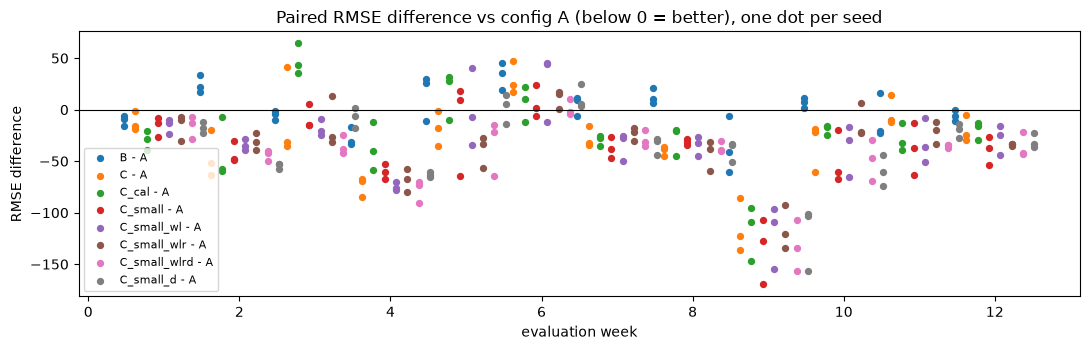

In [13]:
runs = study.runs_table()
figures.paired_differences(runs, reference="A")
seed_table = runs.pivot_table(index="config", columns="seed", values="rmse", aggfunc="mean")
seed_table.columns = [f"seed {s} RMSE" for s in seed_table.columns]
report.publish("5.2", seed_table.reset_index())

Output 5.3


,step,config A,config B,config C,config C_cal,config C_small,config C_small_wl,config C_small_wlr,config C_small_wlrd,config C_small_d,[baseline] damped persistence -> mean last 720
0,1,102.98,147.55,91.38,110.37,98.85,106.67,97.87,58.10,88.13,13.80
1,6,117.38,125.36,75.67,68.86,73.97,76.54,75.95,69.93,91.99,122.63
2,12,112.41,113.37,67.90,64.54,63.97,65.20,63.32,55.81,66.75,109.08
3,24,157.30,148.96,89.31,107.32,91.92,96.73,91.54,90.38,91.18,118.13
4,48,124.26,106.49,97.31,107.21,85.36,81.53,82.85,73.94,90.40,117.52
5,72,143.06,132.40,103.78,105.66,91.75,93.50,105.63,90.94,86.68,144.25
6,120,85.99,101.93,81.60,119.52,79.50,83.70,73.39,58.45,83.59,57.90
7,168,196.81,201.23,162.99,168.54,152.33,158.40,152.69,148.57,151.38,192.65


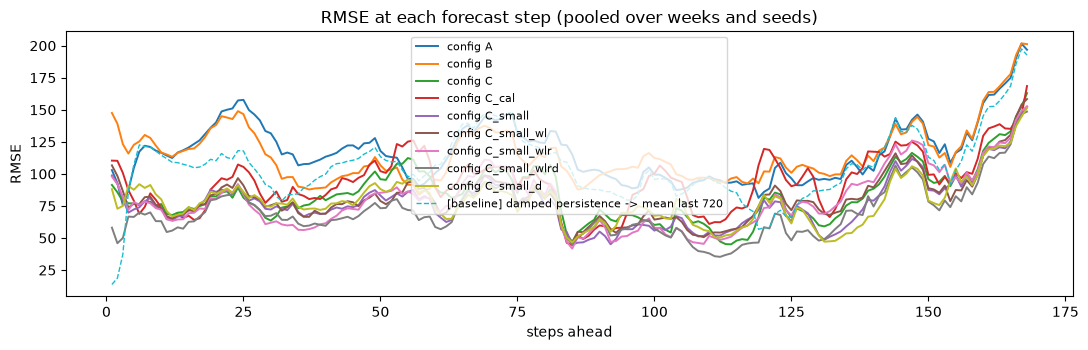

In [14]:
curves = study.horizon_rmse()
figures.horizon_curve(curves)
steps = [1, 6, 12, 24, 48, 72, 120, 168]
report.publish("5.3", curves.loc[steps].reset_index())

Output 5.4


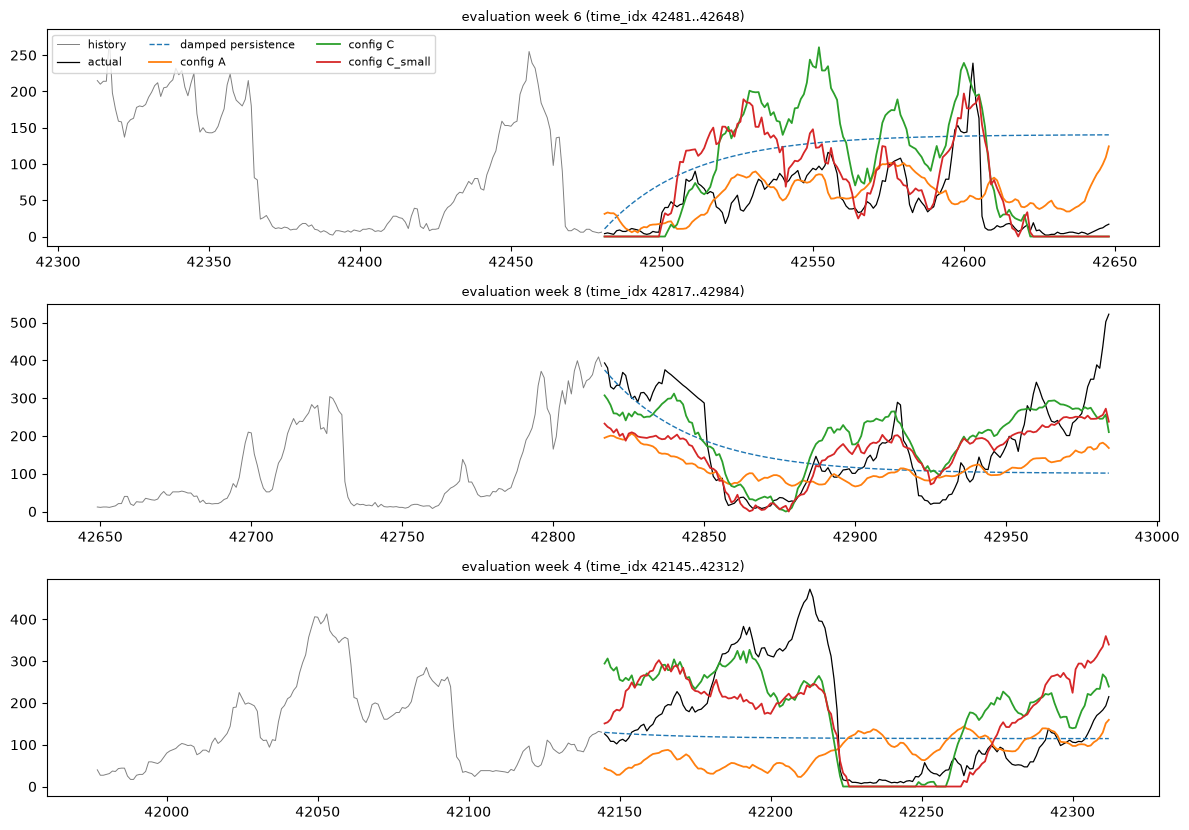

In [15]:
a_blocks = runs[(runs.config == "A") & (runs.seed == seeds[0])].sort_values("rmse")["block"].tolist()
figures.forecast_cases(study, ["A", "C", "C_small"], seeds[0],
                       [a_blocks[0], a_blocks[len(a_blocks) // 2], a_blocks[-1]])
report.publish("5.4")

### Turning trained seeds into one forecast

In [16]:
ANCHOR_PHI = 0.83   # learned damping of the damped-trend models (0.818-0.844 over 6 seeds)
candidates = pd.concat([study.final_candidates(name, seeds, phi=ANCHOR_PHI)
                        for name in ("C", "C_small", "C_small_wlrd")], ignore_index=True)
report.publish("5.5", candidates)

Output 5.5


,config,seeds,anchored,rmse_mean,rmse_std_blocks,mae_mean,smape_mean,diff_vs_single_mean,diff_vs_single_std,P,declared_E
0,C,0,False,84.24,25.79,63.29,86.90,0.60,18.89,23361,7
1,C,0,True,83.50,25.71,62.64,83.37,-0.15,18.41,23361,7
2,C,1,False,76.40,16.17,54.92,81.22,-7.25,9.16,23361,7
3,C,1,True,75.37,16.59,54.37,77.04,-8.28,9.57,23361,7
4,C,2,False,90.30,16.98,67.70,88.59,6.65,14.05,23361,15
5,C,2,True,89.53,17.73,67.06,84.44,5.88,14.79,23361,15
6,C,"0,1,2",False,79.60,16.20,58.79,75.83,-4.05,3.47,70083,29
7,C,"0,1,2",True,78.93,16.43,58.25,72.65,-4.72,4.12,70083,29
8,C_small,0,False,79.22,26.22,59.95,82.12,3.54,10.99,6561,7
9,C_small,0,True,78.69,25.76,59.30,78.35,3.01,10.24,6561,7


### Does a validation win survive on unseen weeks?

In [17]:
report.publish("5.6", replicate.summary(["C_small", "C_small_wlrd"], seeds, phi=ANCHOR_PHI,
                                        preset=preset))

loaded replication-full-C_small-seed0-5a194b1f7f.npz
loaded replication-full-C_small-seed1-677df96265.npz
loaded replication-full-C_small-seed2-3e871ee306.npz
loaded replication-full-C_small_wlrd-seed0-eb12b9b474.npz
loaded replication-full-C_small_wlrd-seed1-df7379a4cc.npz
loaded replication-full-C_small_wlrd-seed2-91e39bfad9.npz
Output 5.6


,config,single_seed_rmse,ensemble_rmse,ensemble_anchored_rmse,ensemble_diff_vs_first,weeks_better_than_first
0,C_small,66.69,64.14,63.01,0.00,0/12
1,C_small_wlrd,71.54,65.59,65.71,1.45,5/12


## 6. Select, Refit, Submit

In [19]:
choice = {
    "config": "C_small",   # beats C on validation; C_small_wlrd's win did not replicate (5.6)
    "seeds": [0, 1, 2],
    "recipe": "anneal",    # attempt #2: refit on the full history, whole schedule in best_epoch epochs
    "anchor": False,       # attempt #2 was not anchored
}

loaded full-refit-C_small-seed0-a936d7fdf5.pt
loaded full-refit-C_small-seed1-d8f78b799e.pt
loaded full-refit-C_small-seed2-022687a153.pt
Output 6.1


,config,seeds,anchored,P,E,first_time_idx,last_time_idx,forecast_mean,forecast_min,forecast_max,recent_720_mean
0,C_small,"0,1,2",False,19683,33,43657,43824,97.67,3.4,181.65,90.02


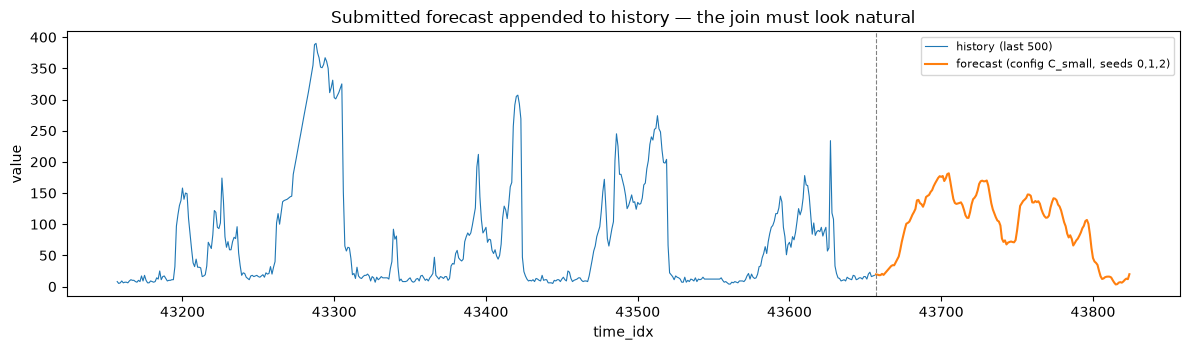

declare P=19683 E=33
paste string written to /Users/alihaider/Documents/MS-AI/Deep Learning for Time, Space, and Graphs/Assignments/DL4STG-PA1/Question 2 - Leaderboard/results/leaderboard_submission.txt (first value = time_idx 43657)


In [20]:
forecast, P, E = study.refit(choice)

line = ",".join(f"{v:.4f}" for v in forecast)
assert forecast.shape == (168,) and len(line.split(",")) == 168, "need exactly 168 values"
assert np.isfinite(forecast).all() and (forecast >= 0).all(), "values must be finite and >= 0"
recent = study.y[-720:].mean()
assert 0.2 * recent < forecast.mean() < 5 * recent, "forecast level implausible: check scaling"

path = data.RESULTS_DIR / "leaderboard_submission.txt"
path.write_text(line)
seed_label = ",".join(map(str, choice["seeds"]))
figures.submission(study.y, forecast, f"forecast (config {choice['config']}, seeds {seed_label}"
                                      f"{', anchored' if choice['anchor'] else ''})")
report.publish("6.1", pd.DataFrame([dict(config=choice["config"], seeds=seed_label,
                                         anchored=choice["anchor"], P=P, E=E,
                                         first_time_idx=43657, last_time_idx=43824,
                                         forecast_mean=forecast.mean(), forecast_min=forecast.min(),
                                         forecast_max=forecast.max(), recent_720_mean=recent)]))
print(f"declare P={P} E={E}")
print(f"paste string written to {path} (first value = time_idx 43657)")